In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] =(10, 6)

df = pd.read_csv('../data/creditcard.csv')

print(f"Размер датасета: {df.shape}")
print(f'Доля моенничества: {df["Class"].mean () * 100:.3f}%')

Размер датасета: (284807, 31)
Доля моенничества: 0.173%


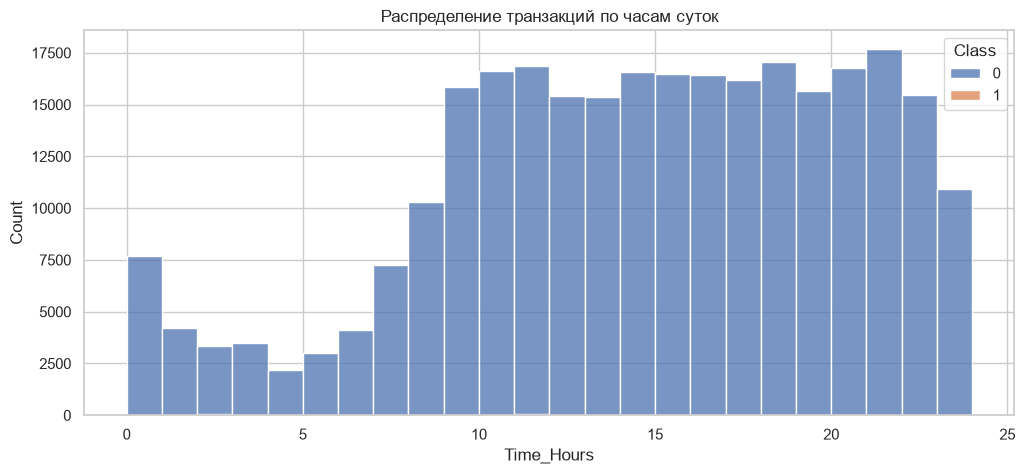

In [24]:
# Конвертируем секунды в часы, чтобы поймать суточные паттерны
df['Time_Hours'] = (df['Time'] % (24 * 3600)) / 3600

# Визуализируем распределение времени для мошеннических и легитимных транзакций
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Time_Hours', hue='Class', multiple='stack', bins=24)
plt.title('Распределение транзакций по часам суток')
plt.show()

# Удаляем исходный признак Time, так как он больше не нужен
df = df.drop('Time', axis=1)

In [26]:
# Отделяем признаки и целевую переменную
X = df.drop('Class', axis=1)
y = df['Class']

# СТРАТИФИЦИРОВАННОЕ разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # <--- САМОЕ ВАЖНОЕ
)

print(f"Доля Fraud в y_train: {y_train.mean() * 100:.3f}%")
print(f"Доля Fraud в y_test: {y_test.mean() * 100:.3f}%")

Доля Fraud в y_train: 0.173%
Доля Fraud в y_test: 0.172%
